Body Fat percent calculator

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

In [3]:
# Random seed
rs = 42
df = pd.read_csv('BodyFat - Extended.csv')
df

,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.30,Y,M,23,69.9700,1.7200,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.10,Y,M,22,78.5900,1.8400,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.30,Y,M,22,69.8500,1.6800,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.40,Y,M,26,83.8000,1.8400,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.70,Y,M,24,83.5800,1.8100,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,30.40,N,F,23,59.8752,1.5621,31.3,89.0,71.0,98.5,56.0,36.2,21.0,28.0,24.5,16.3
432,7.47,N,F,21,48.5352,1.5748,29.5,79.0,62.5,89.0,49.0,33.0,20.0,25.0,22.0,15.5
433,11.98,N,F,20,51.7104,1.5748,31.5,81.5,61.5,90.0,49.5,32.0,19.5,27.5,22.5,15.0
434,11.24,N,F,22,50.8032,1.6510,30.5,85.0,64.0,88.0,45.0,32.0,19.5,24.0,21.5,15.0


Body fat - y train, multiply with 0.01 to use it for logistic regression also

Original - if data from original dataset or not(all data are real but from different author). need to drop as not required

Sex - M to 0, F to 1

weight - kg

Height - meter -> cm

others are cm

In [4]:
df.drop(columns=['Original'], inplace=True)
df

,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.30,M,23,69.9700,1.7200,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.10,M,22,78.5900,1.8400,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.30,M,22,69.8500,1.6800,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.40,M,26,83.8000,1.8400,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.70,M,24,83.5800,1.8100,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,30.40,F,23,59.8752,1.5621,31.3,89.0,71.0,98.5,56.0,36.2,21.0,28.0,24.5,16.3
432,7.47,F,21,48.5352,1.5748,29.5,79.0,62.5,89.0,49.0,33.0,20.0,25.0,22.0,15.5
433,11.98,F,20,51.7104,1.5748,31.5,81.5,61.5,90.0,49.5,32.0,19.5,27.5,22.5,15.0
434,11.24,F,22,50.8032,1.6510,30.5,85.0,64.0,88.0,45.0,32.0,19.5,24.0,21.5,15.0


In [5]:
df['Sex'] = df['Sex'].map({'M':0,'F':1})
df

,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.30,0,23,69.9700,1.7200,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.10,0,22,78.5900,1.8400,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.30,0,22,69.8500,1.6800,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.40,0,26,83.8000,1.8400,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.70,0,24,83.5800,1.8100,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,30.40,1,23,59.8752,1.5621,31.3,89.0,71.0,98.5,56.0,36.2,21.0,28.0,24.5,16.3
432,7.47,1,21,48.5352,1.5748,29.5,79.0,62.5,89.0,49.0,33.0,20.0,25.0,22.0,15.5
433,11.98,1,20,51.7104,1.5748,31.5,81.5,61.5,90.0,49.5,32.0,19.5,27.5,22.5,15.0
434,11.24,1,22,50.8032,1.6510,30.5,85.0,64.0,88.0,45.0,32.0,19.5,24.0,21.5,15.0


In [6]:
df['Height'] = df['Height'].multiply(100)
df

,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.30,0,23,69.9700,172.00,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.10,0,22,78.5900,184.00,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.30,0,22,69.8500,168.00,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.40,0,26,83.8000,184.00,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.70,0,24,83.5800,181.00,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,30.40,1,23,59.8752,156.21,31.3,89.0,71.0,98.5,56.0,36.2,21.0,28.0,24.5,16.3
432,7.47,1,21,48.5352,157.48,29.5,79.0,62.5,89.0,49.0,33.0,20.0,25.0,22.0,15.5
433,11.98,1,20,51.7104,157.48,31.5,81.5,61.5,90.0,49.5,32.0,19.5,27.5,22.5,15.0
434,11.24,1,22,50.8032,165.10,30.5,85.0,64.0,88.0,45.0,32.0,19.5,24.0,21.5,15.0


Loading the dataset

In [7]:
X, y = df.drop(columns=['BodyFat']), pd.Series(df['BodyFat'])
X, y

(     Sex  Age   Weight  Height  Neck  Chest  Abdomen    Hip  Thigh  Knee  \
 0      0   23  69.9700  172.00  36.2   93.1     85.2   94.5   59.0  37.3   
 1      0   22  78.5900  184.00  38.5   93.6     83.0   98.7   58.7  37.3   
 2      0   22  69.8500  168.00  34.0   95.8     87.9   99.2   59.6  38.9   
 3      0   26  83.8000  184.00  37.4  101.8     86.4  101.2   60.1  37.3   
 4      0   24  83.5800  181.00  34.4   97.3    100.0  101.9   63.2  42.2   
 ..   ...  ...      ...     ...   ...    ...      ...    ...    ...   ...   
 431    1   23  59.8752  156.21  31.3   89.0     71.0   98.5   56.0  36.2   
 432    1   21  48.5352  157.48  29.5   79.0     62.5   89.0   49.0  33.0   
 433    1   20  51.7104  157.48  31.5   81.5     61.5   90.0   49.5  32.0   
 434    1   22  50.8032  165.10  30.5   85.0     64.0   88.0   45.0  32.0   
 435    1   24  47.6280  160.02  26.0   79.3     63.0   86.6   46.0  33.5   
 
      Ankle  Biceps  Forearm  Wrist  
 0     21.9    32.0     27.4   17.1 

In [8]:
X.describe()

,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000
mean,0.422018,34.545872,72.282203,173.404794,35.250917,94.158028,82.816055,98.652294,56.039679,37.365596,22.351835,29.897248,26.482110,17.139908
std,0.494449,15.500099,15.464366,9.835892,3.837908,10.931688,14.652729,6.895034,6.194143,2.768403,1.780513,3.944843,3.155306,1.582291
min,0.000000,1.000000,42.184800,75.000000,26.000000,43.000000,58.000000,82.500000,38.000000,24.700000,18.000000,20.500000,20.000000,13.500000
25%,0.000000,21.000000,59.875200,166.878000,31.500000,85.500000,70.000000,94.000000,51.500000,35.400000,21.000000,26.950000,23.700000,16.000000
50%,0.000000,28.500000,70.815800,173.000000,35.450000,93.050000,82.850000,98.300000,56.000000,37.500000,22.300000,29.800000,26.650000,17.300000
75%,1.000000,46.000000,81.560000,180.000000,38.300000,101.425000,93.225000,102.500000,60.000000,39.000000,23.300000,32.625000,29.200000,18.400000
max,1.000000,81.000000,164.720000,197.000000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [9]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Sex      436 non-null    int64  
 1   Age      436 non-null    int64  
 2   Weight   436 non-null    float64
 3   Height   436 non-null    float64
 4   Neck     436 non-null    float64
 5   Chest    436 non-null    float64
 6   Abdomen  436 non-null    float64
 7   Hip      436 non-null    float64
 8   Thigh    436 non-null    float64
 9   Knee     436 non-null    float64
 10  Ankle    436 non-null    float64
 11  Biceps   436 non-null    float64
 12  Forearm  436 non-null    float64
 13  Wrist    436 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 47.8 KB


In [10]:
y.describe()
y.info()

<class 'pandas.Series'>
RangeIndex: 436 entries, 0 to 435
Series name: BodyFat
Non-Null Count  Dtype  
--------------  -----  
436 non-null    float64
dtypes: float64(1)
memory usage: 3.5 KB


Plotting the data

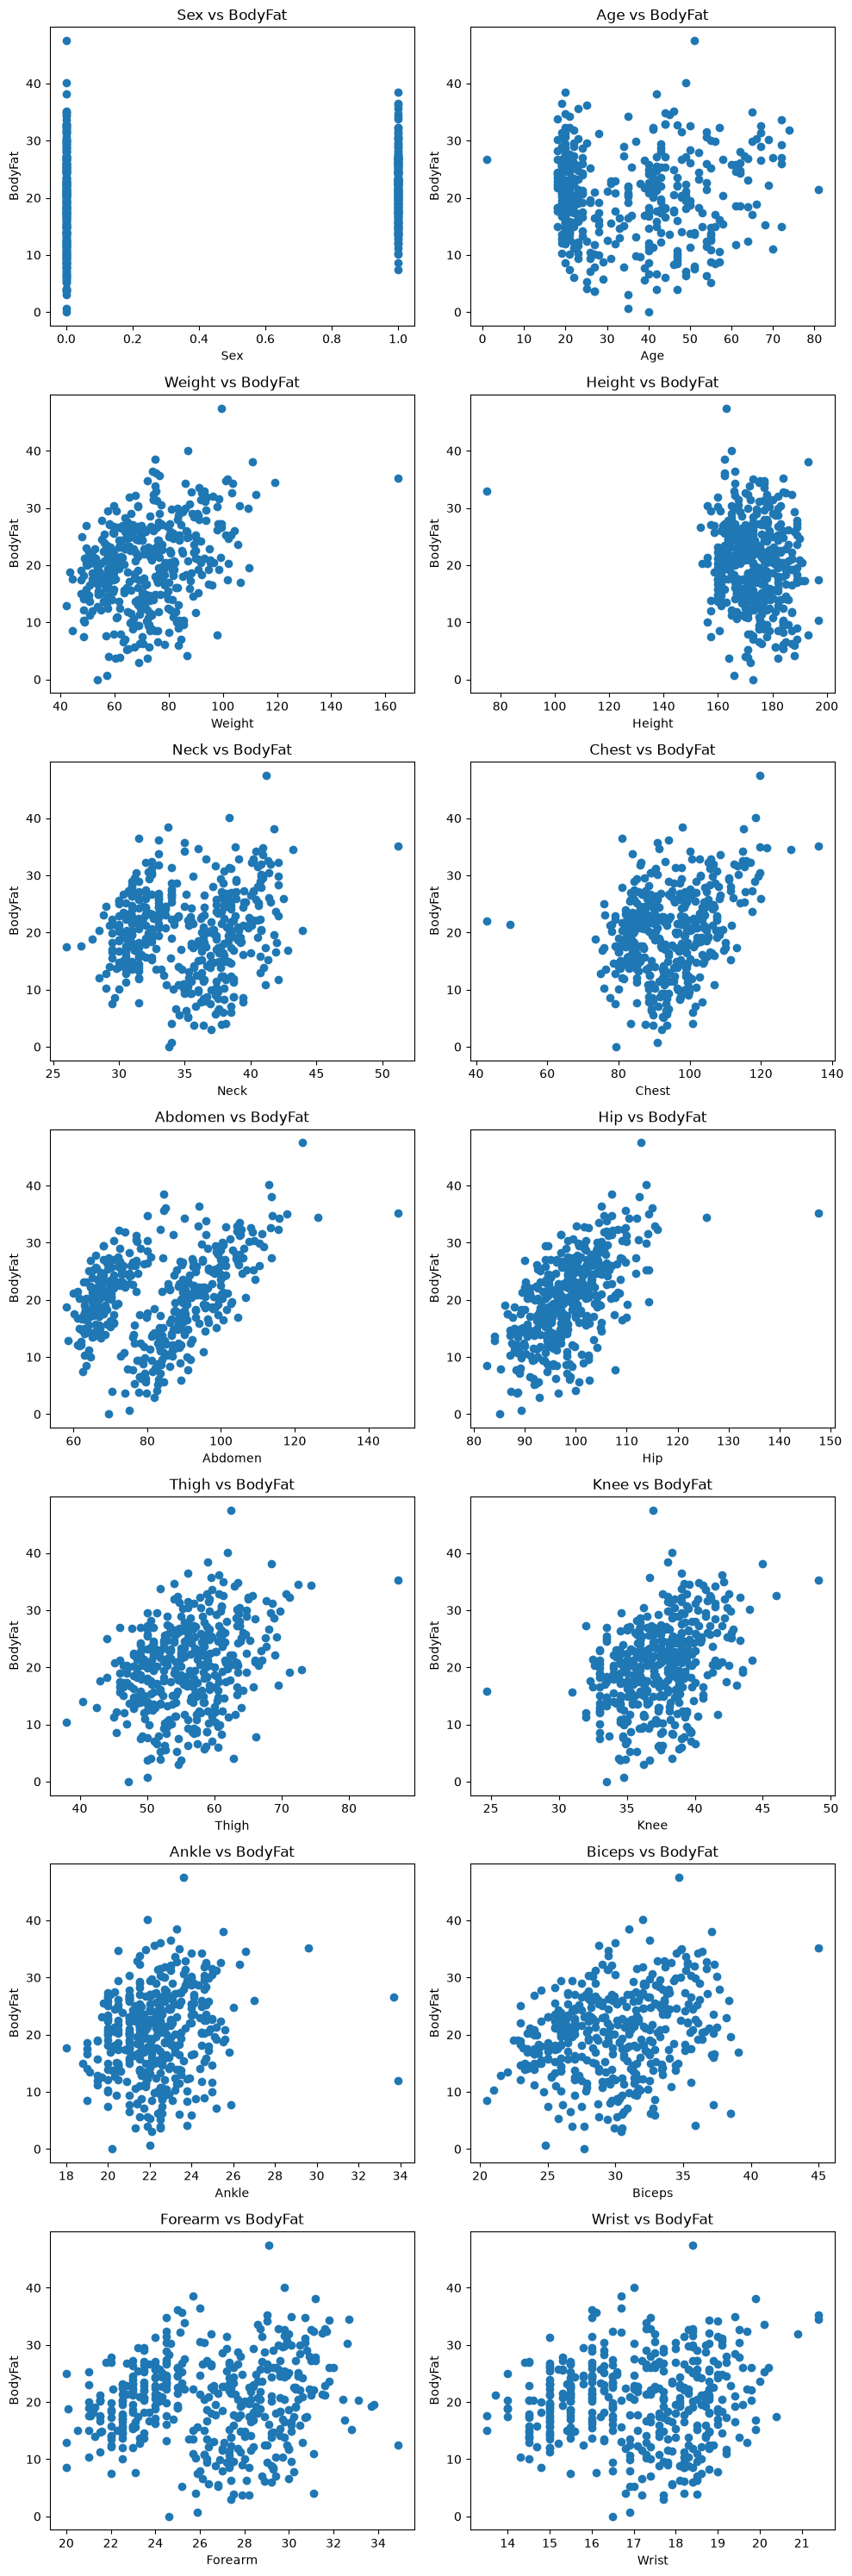

In [11]:
plt.subplots(7,2, figsize=(10,30))
for i, col in enumerate(X.columns):
    plt.subplot(7,2,i+1)
    plt.scatter(X[col], y)
    plt.xlabel(col)
    plt.ylabel('BodyFat')
    plt.title(f'{col} vs BodyFat')
plt.tight_layout()
plt.show()

Test data spliting and feature selection w.r.t the plots

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_test.shape, y_val.shape

((348, 14), (44, 14), (44, 14), (348,), (44,), (44,))

declaring the models dict 

In [16]:
models = dict({
    'linear_regression' : Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', LinearRegression(n_jobs=-1,))
    ]),
    'ridge' : Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('imputer', SimpleImputer(strategy='mean')),
            ('model', Ridge(alpha=0.369, max_iter=1000, random_state=rs))
        ]),
    'lasso' : Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', Lasso(alpha=0.0000001, max_iter=1000, random_state=rs))
    ]),
    'elasticnet' : Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', ElasticNet(alpha=0.000001, l1_ratio=0.5, max_iter=1000, random_state=rs))
    ]),
    'random_forest' : Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('func', RandomForestRegressor(n_estimators=900, max_depth=None, min_samples_leaf=2, random_state=rs, n_jobs=-1))
    ]),
    'neural network' : Pipeline(steps=[
        ('StandardScaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', MLPRegressor(hidden_layer_sizes=(300, 100), activation='relu', solver='adam', max_iter=2000, random_state=rs))
    ])
})

scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val,y_pred)
    r2 = r2_score(y_val,y_pred)
    mse_test = mean_squared_error(y_test, model.predict(X_test))
    r2_test = r2_score(y_test, model.predict(X_test))
    scores[name] = {'mse': mse, 'r2': r2}
    print(f'{name} -> mse: {mse:.4f}, r2: {r2:.4f}, mse_test: {mse_test:.4f}, r2_test: {r2_test:.4f}')

linear_regression -> mse: 14.1874, r2: 0.6371, mse_test: 17.7345, r2_test: 0.6544
ridge -> mse: 14.1907, r2: 0.6370, mse_test: 17.5345, r2_test: 0.6583
lasso -> mse: 14.1874, r2: 0.6371, mse_test: 17.7345, r2_test: 0.6544
elasticnet -> mse: 14.1874, r2: 0.6371, mse_test: 17.7344, r2_test: 0.6544
random_forest -> mse: 14.7302, r2: 0.6232, mse_test: 20.1912, r2_test: 0.6065
neural network -> mse: 24.2726, r2: 0.3791, mse_test: 21.6948, r2_test: 0.5772


*Ridge is the best model so far*


In [17]:
Best_model = models['ridge'].fit(X,y)
sample_X = pd.DataFrame([{
    "Sex": 0,
    "Age": 23,
    "Weight": 108,
    "Height": 173,
    "Neck": 42,
    "Chest": 115,
    "Abdomen": 110,
    "Hip": 110,
    "Thigh": 65,
    "Knee": 42,
    "Ankle": 25,
    "Biceps": 38,
    "Forearm": 31,
    "Wrist": 19
}])
Best_model.predict(sample_X)

array([26.98607302])